In [1]:
from sklearn import datasets
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv(r'C:\Users\Phillip\Desktop\Python\Python Notebooks (Mine)\Datasets\Iris.csv', index_col = 'Id')
df.rename(columns = {'SepalLengthCm' : 'SepalLength',
                    'SepalWidthCm' : 'SepalWidth',
                    'PetalLengthCm' : 'PetalLength',
                    'PetalWidthCm' : 'PetalWidth'},
                    inplace = True)

In Seaborn Iris => Petal Length and Petal Width are good separators

Text(0.5, 0.98, 'Histogram of all Features')

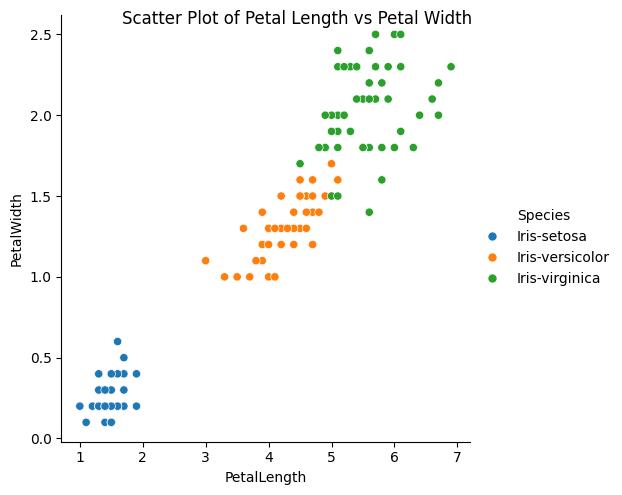

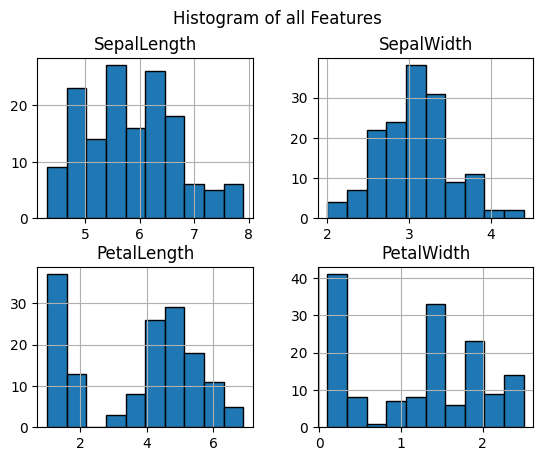

In [11]:
g = sns.relplot(data = df,
                hue = 'Species',
                kind = 'scatter',
                x = 'PetalLength',
                y = 'PetalWidth')

plt.gcf().suptitle('Scatter Plot of Petal Length vs Petal Width')

# To plot histograms of each feature => plot from dataframe
univariate_dist = df.hist(
    edgecolor = 'black',
    layout = (2,2)
)

fig = plt.gcf()
fig.suptitle('Histogram of all Features')

### Classification Terms

    - Attributes : Property of an observation that can be used to classify the point. Here, attributes are petal length, etc...
    - Target Variable : variable that is/should be the output (species)

In [13]:
# importing alll the necessary packages to use the various classification algorithms
from sklearn.linear_model import LogisticRegression # for Logistic Regression Algorithm
from sklearn.model_selection import train_test_split # to split the dataset for training and testing 
from sklearn.neighbors import KNeighborsClassifier # KNN classifier
from sklearn import svm # for suport vector machine algorithm
from sklearn import metrics # for checking the model accuracy
from sklearn.tree import DecisionTreeClassifier # for using DTA

Must be careful of multicollinearity (high correlation between features).

Use a correlation plot to find features that are least correlated => sepal width and length have -0.11 

Will use Sepal width and length to classify

Will also choose Petal Width and Length (0,96 correlation) to show why we should avoid

<Axes: >

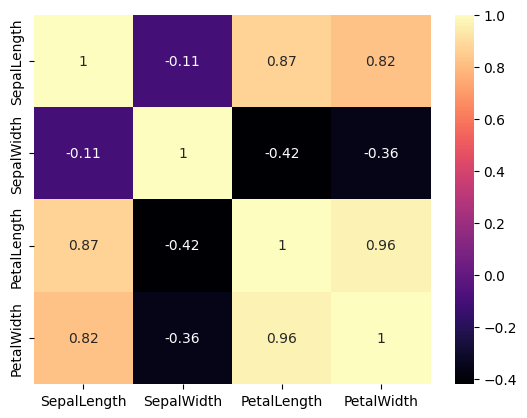

In [20]:
# Can see the correlation
feature_df = df[['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth']].copy()
# Plot using seaborn
sns.heatmap(
    data = feature_df.corr(),
    annot = True,
    cmap = 'magma'
)


In [55]:
# Split the dataset up
test_size = 0.30

df_ = df.reset_index(drop = True)
training, testing = train_test_split(
    df_,
    test_size=test_size
    )
# Check the numbers make sense
print(f'Training Dataset size : {training.shape}', f'\nTesting Dataset size : {testing.shape}')
# Separate training and testing dataframes into predictors and target
X_train = training[['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth']]
y_train = training['Species']

X_test = testing[['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth']]
y_test = testing['Species']


Training Dataset size : (105, 5) 
Testing Dataset size : (45, 5)


In [58]:
y_train

75     Iris-versicolor
44         Iris-setosa
34         Iris-setosa
23         Iris-setosa
8          Iris-setosa
            ...       
133     Iris-virginica
103     Iris-virginica
115     Iris-virginica
7          Iris-setosa
141     Iris-virginica
Name: Species, Length: 105, dtype: object

### SVM

In [59]:
# Select SVM model
SVM = svm.SVC()

# Train the model 
SVM.fit(
    X = X_train,
    y = y_train,
    sample_weight= None # Per sample weights - rescale C per sample => 
        )               # higher weights force classifer to emphasize those 
                        # points more
        
# Now make predictions on the testing data
SVM_prediction = SVM.predict(X_test)

Diagnostics of SVM


In [68]:
# Accuracy is
accuracy_SVM = metrics.accuracy_score(SVM_prediction, y_test)
print(f'Accuracy of SVM {accuracy_SVM*100}%')

Accuracy of SVM 91.11111111111111%


### Logistic Regression

In [71]:
# Call LogisticRegression object
LogReg = LogisticRegression()

# Fit the model
LogReg.fit(X = X_train, y = y_train)

# Predict
LogReg_Prediction = LogReg.predict(X_test)

# Metrics
print(f'Accuracy is {metrics.accuracy_score(LogReg_Prediction, y_test) * 100}%')

Accuracy is 91.11111111111111%


### Decision Tree

In [75]:
# Call Decision Tree
DecTree = DecisionTreeClassifier()

# Fit the model
DecTree.fit(X_train, y_train)

# Predict
DecTree_Prediction = DecTree.predict(X_test)

# Metrics
print(f'Accuracy is {metrics.accuracy_score(DecTree_Prediction, y_test) * 100}%')

Accuracy is 91.11111111111111%


### KNN

In [79]:
KNN = KNeighborsClassifier(n_neighbors = 3,
                           leaf_size = 30,# Default
                           p = 2, # Minkowski metric (p = 2 is euclidean distance)
                           weights = 'uniform', # All points in each neighbour are weighted equally
                           )

KNN.fit(X_train, y_train)

KNN_Pred = KNN.predict(X_test)

print(metrics.accuracy_score(KNN_Pred, y_test) * 100)

95.55555555555556


{1: 95.55555555555556, 2: 91.11111111111111, 3: 95.55555555555556, 4: 88.88888888888889, 5: 93.33333333333333, 6: 88.88888888888889, 7: 91.11111111111111, 8: 88.88888888888889, 9: 88.88888888888889, 10: 88.88888888888889}


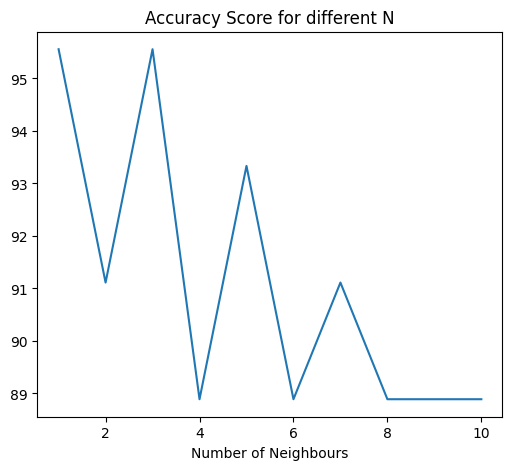

In [89]:
# Code for different numbers of n in KNN

accuracy = {}

for i in range(1,11):
    
    KNN = KNeighborsClassifier(n_neighbors=i)
    KNN.fit(X_train, y_train)
    KNN_Pred = KNN.predict(X_test)
    accuracy[i] = (metrics.accuracy_score(y_pred= KNN_Pred, y_true = y_test) * 100)

fig, axs = plt.subplots(1, figsize = (6,5))

axs.plot(accuracy.keys(), accuracy.values())

axs.set_title('Accuracy Score for different N')
axs.set_xlabel('Number of Neighbours')

print(accuracy)

## Classifying based only on Pair of Features

In [108]:
# Sepal and Petal Features Only
Sepal = df[['SepalLength', 'SepalWidth', 'Species']].copy()
Petal = df[['PetalLength', 'PetalWidth', 'Species']].copy()

# Split up into training and testing sets
Sepal_Train, Sepal_Test = train_test_split(Sepal, test_size = test_size, random_state=0)
Petal_Train, Petal_Test = train_test_split(Petal, test_size = test_size, random_state=0)

In [110]:
# Sepal Only
X_Sepal_Train = Sepal_Train[['SepalLength', 'SepalWidth']]
y_Sepal_Train = Sepal_Train.Species

X_Sepal_Test = Sepal_Test[['SepalLength', 'SepalWidth']]
y_Sepal_Test = Sepal_Test.Species

# SVM

SVM = svm.SVC()
SVM.fit(X_Sepal_Train, y_Sepal_Train)
SVM_Prediction_Sepal = SVM.predict(X_Sepal_Test)
print(f'Sepal Features SVM Accuracy Score : \
      {metrics.accuracy_score(y_pred = SVM_Prediction_Sepal, y_true = y_Sepal_Test) * 100}%')

# Logistic Regression
LogReg = LogisticRegression()
LogReg.fit(X_Sepal_Train, y_Sepal_Train)
LogReg_Pred_Sepal = LogReg.predict(X_Sepal_Test)
print(f'Sepal Features Logistic Regression Accuracy Score : \
      {metrics.accuracy_score(y_pred = LogReg_Pred_Sepal, y_true = y_Sepal_Test) * 100}%')

# KNN
KNN = KNeighborsClassifier(n_neighbors=3)
KNN.fit(X_Sepal_Train, y_Sepal_Train)
KNN_Pred_Sepal = KNN.predict(X_Sepal_Test)
print(f'Sepal Features KNN  Accuracy Score : \
      {metrics.accuracy_score(y_pred = KNN_Pred_Sepal, y_true = y_Sepal_Test) * 100}%')

# Decision Tree
DT = LogisticRegression()
DT.fit(X_Sepal_Train, y_Sepal_Train)
DT_Pred = LogReg.predict(X_Sepal_Test)
print(f'Sepal Features Decision Tree Accuracy Score : \
      {metrics.accuracy_score(y_pred = DT_Pred, y_true = y_Sepal_Test) * 100}%')

Sepal Features SVM Accuracy Score :       80.0%
Sepal Features Logistic Regression Accuracy Score :       82.22222222222221%
Sepal Features KNN  Accuracy Score :       73.33333333333333%
Sepal Features Decision Tree Accuracy Score :       82.22222222222221%


In [128]:
# Petal Only
X_Petal_Train = Petal_Train[['PetalLength', 'PetalWidth']]
y_Petal_Train = Petal_Train.Species

X_Petal_Test = Petal_Test[['PetalLength', 'PetalWidth']]
y_Petal_Test = Petal_Test.Species

# SVM

SVM = svm.SVC()
SVM.fit(X_Petal_Train, y_Petal_Train)
SVM_Prediction_Petal = SVM.predict(X_Petal_Test)
print(f'Petal Features SVM Accuracy Score : \
      {metrics.accuracy_score(y_pred = SVM_Prediction_Petal, y_true = y_Petal_Test) * 100}%')

# Logistic Regression
LogReg = LogisticRegression()
LogReg.fit(X_Petal_Train, y_Petal_Train)
LogReg_Pred_Petal = LogReg.predict(X_Petal_Test)
print(f'Petal Features Logistic Regression Accuracy Score : \
      {metrics.accuracy_score(y_pred = LogReg_Pred_Petal, y_true = y_Petal_Test) * 100}%')

# KNN
KNN = KNeighborsClassifier(n_neighbors=3)
KNN.fit(X_Petal_Train, y_Petal_Train)
KNN_Pred_Petal = KNN.predict(X_Petal_Test)
print(f'Petal Features KNN  Accuracy Score : \
      {metrics.accuracy_score(y_pred = KNN_Pred_Petal, y_true = y_Petal_Test) * 100}%')

# Decision Tree
DT_x = DecisionTreeClassifier()
DT_x.fit(X_Petal_Train, y_Petal_Train)
DT_Predx= DT_x.predict(X_Petal_Test)
print(f'Petal Features Decision Tree Accuracy Score : \
      {metrics.accuracy_score(DT_Predx,y_Petal_Test) * 100}%')

Petal Features SVM Accuracy Score :       97.77777777777777%
Petal Features Logistic Regression Accuracy Score :       97.77777777777777%
Petal Features KNN  Accuracy Score :       97.77777777777777%
Petal Features Decision Tree Accuracy Score :       95.55555555555556%
